# Matrix-Vektor Operationen mit `NumPy`

NumPy ist eine leistungsstarke Bibliothek für numerische Berechnungen in Python, die insbesondere für die Arbeit mit Arrays und Matrizen optimiert ist.

__Matrizen__ sind rechteckige Anordnungen von Zahlen, die in Zeilen und Spalten organisiert sind. Sie werden häufig in der linearen Algebra verwendet, um lineare Gleichungssysteme zu lösen, Transformationen durchzuführen und Daten zu analysieren.

$$
A = \begin{pmatrix}
a_{11} & a_{12} & \cdots & a_{1n}\\
a_{21} & a_{22} & \cdots & a_{2n}\\
\vdots & \vdots & \ddots & \vdots\\
a_{m1} & a_{m2} & \cdots & a_{mn}\\
\end{pmatrix} \in \mathbb{R}^{m\times n}
$$





### Matix-Matrix und Matrix-Vektor Operationen
- `*`: Elementweise Multiplikation von Arrays gleicher Form.
    - Alternative: `np.multiply()`
- `@` oder `np.dot()`: Matrix-Vektor- oder Matrix-Matrix-Multiplikation.
    - Für 1D-Arrays (Vektoren) wird das Skalarprodukt berechnet.
    - Für 2D-Arrays (Matrizen) wird die reguläre Matrixmultiplikation durchgeführt
        - Dimensionen müssen übereinstimmen: $A\in \mathbb{R}^{m\times n}, B\in \mathbb{R}^{n\times p} \Rightarrow C = A B \in \mathbb{R}^{m\times p}$

        $$
        C_{ij} = \sum_{k=1}^{n} A_{ik} B_{kj} \quad \text{für } i=1,\ldots,m \text{ und } j=1,\ldots,p
        $$
        
    - Alternative: `np.matmul()`
- `+`: Elementweise Addition von Arrays gleicher Form
- `-`: Elementweise Subtraktion von Arrays gleicher Form
- `/` : Elementweise Division von Arrays gleicher Form
- `np.transpose()`: Transponieren einer Matrix (Kurzform: `array.T`)


In [1]:
import numpy as np
A = np.array([[1, 2, 3], [4, 5, 6]])
B = np.ones((3,2))
C = np.random.rand(2,3)
print(A)    # Originalmatrix
print(A@B)  # Matrix-Matrix Multiplikation
print(A*C)  # Elementwiese Matrix-Matrix Multiplikation
A = np.transpose(A)
print(A)    # Transponierte Matrix
print(A.T)  # Transponierte Matrix (Alternative)

[[1 2 3]
 [4 5 6]]
[[ 6.  6.]
 [15. 15.]]
[[0.07100451 0.92218951 1.01226451]
 [0.45339099 2.79991732 5.43908287]]
[[1 4]
 [2 5]
 [3 6]]
[[1 2 3]
 [4 5 6]]


### Broadcasting Regeln
- Wenn die Dimensionen der Arrays nicht übereinstimmen, versucht NumPy, sie durch Broadcasting kompatibel zu machen.
- Zwei Dimensionen sind kompatibel, wenn sie gleich sind oder eine von ihnen 1 ist.
- NumPy dehnt die Dimension mit der Größe 1 so aus, dass sie der anderen Dimension entspricht.
- Wenn die Arrays unterschiedliche Anzahlen von Dimensionen haben, fügt NumPy der kleineren Anzahl von Dimensionen linksseitig Dimensionen hinzu, bis die Anzahlen übereinstimmen.


Im folgenden Beispiel ist $A\in \mathbb{R}^{3\times 1}$ und $B\in \mathbb{R}^{1\times 4}$. Durch Broadcasting wird $A$ zu einer $3\times 4$ Matrix und $B$ zu einer $3\times 4$ Matrix erweitert, sodass die Addition möglich ist.

In [2]:
A = np.ones((3,1))
B = np.ones((1,4))
C = A + B  # Ergebnis ist ein 3x4 Array, da A und B durch Broadcasting kompatibel gemacht wurden
print("A:")
print(A)
print("B:")
print(B)
print("C:")
print(C)

A:
[[1.]
 [1.]
 [1.]]
B:
[[1. 1. 1. 1.]]
C:
[[2. 2. 2. 2.]
 [2. 2. 2. 2.]
 [2. 2. 2. 2.]]


Im nächsten Beispiel wird $A\in \mathbb{R}^{3\times 4}$ mit dem Vektor $B\in \mathbb{R}^{4}$ elementweise multipliziert. Durch Broadcasting wird $B$ zu einer $3\times 4$ Matrix erweitert (es werden linkseitig Dimensionen hinzugefügt), sodass die Multiplikation möglich ist.

In [3]:
A = np.ones((3,4))
B = np.array([1, 2, 3, 4])
C = A * B
print("A:")
print(A)
print("B:")
print(B)
print("C:")
print(C)

A:
[[1. 1. 1. 1.]
 [1. 1. 1. 1.]
 [1. 1. 1. 1.]]
B:
[1 2 3 4]
C:
[[1. 2. 3. 4.]
 [1. 2. 3. 4.]
 [1. 2. 3. 4.]]


Durch Broadcasting kann man Arrays auch sehr einfach mit Skalaren kombinieren. Ein Skalar wird dabei so erweitert, dass er die gleiche Form wie das andere Array hat.

In [3]:
import numpy as np
A = np.array([[1, 2, 3], [4, 5, 6]])
print(A+1) # Addiert 1 zu jedem Element von A
print(A*2) # Multipliziert jedes Element von A mit 2
print(A**2) # Quadriert jedes Element von A

[[2 3 4]
 [5 6 7]]
[[ 2  4  6]
 [ 8 10 12]]
[[ 1  4  9]
 [16 25 36]]


__Wichtig__: Matrix-Matrix-Multiplikation `@` folgt etwas anderen Broadcasting Regeln.
- Ist der erste Operand 1D, so werden linkseitig Dimensionen hinzugefügt.
- Ist der zweite Operand 1D, so werden rechtseitig Dimensionen hinzugefügt.
- Nach der Multiplikation werden alle hinzugefügten Dimensionen entfernt.

In [ ]:
import numpy as np
A = np.array([[1, 2, 3], [4, 5, 6]])
B = np.array([1, 2])
C = np.array([1,2,3])

print(B @ A) # Hier wird das (2,)-Array B als (1,2)-Array interpretiert, Ergebnis ist (1,3) und wird als (3,)-Array ausgegeben
print(A @ C) # Hier wird das (3,)-Array C als (3,1)-Array interpretiert, Ergebnis ist (2,1) und wird als (2,)-Array ausgegeben

[ 9 12 15]
[14 32]


## Logische Operationen auf Arrays
- `np.all(array)`: Gibt `True` zurück, wenn alle Elemente des Arrays `True` sind.
- `np.any(array)`: Gibt `True` zurück, wenn mindestens ein Element des Arrays `True` ist.
- `array1 & array2`: Elementweise logisches UND zwischen zwei Arrays gleicher Form.
- `array1 | array2`: Elementweise logisches ODER zwischen zwei Arrays gleicher Form.
- `~array`: Elementweise logisches NICHT eines Arrays gleicher Form.
- `array1 == array2`: Elementweise Gleichheitsprüfung zwischen zwei Arrays gleicher Form.
- `array1 != array2`: Elementweise Ungleichheitsprüfung zwischen zwei Arrays gleicher Form.
- `array1 < array2`: Elementweise Kleiner-als-Prüfung zwischen zwei Arrays gleicher Form.
- `array1 <= array2`: Elementweise Kleiner-gleich-Prüfung zwischen zwei Arrays gleicher Form.

In [11]:
a = np.array([1,2,3,4,5])
b = np.array([2,3,4,5,6])
c = np.array([1,2,3,4,6])
print("Is a[i]<b[i] for all i?", np.all(a<b) )
print("Is a[i]<c[i] for all i?", np.all(a < c))
print("Is a[i]<c[i] for any i?", np.any(a < c))

Is a[i]<b[i] for all i? True
Is a[i]<c[i] for all i? False
Is a[i]<c[i] for any i? True


In [7]:
a = np.arange(100)
b = (a % 2 == 0)
c = a % 3 == 0
d = a % 5 == 0
result = a[ b & c & d ]
print(f"Es gibt {len(result)} Zahlen <100, die durch 2, 3 und 5 teilbar sind: {result}")

Es gibt 4 Zahlen <100, die durch 2, 3 und 5 teilbar sind: [ 0 30 60 90]


__Achtung__: Im Gegensatz zu `and`, `or` die für einzelne boolesche Werte verwendet werden, kann man `&` und `|` nicht einfach verketten.
```python
  a < b < c  # FALSCH
  (a < b) & (b < c)  # RICHTIG
```
In der ersten Zeile wird zuerst `a < b` ausgewertet, was ein Array von booleschen Werten ergibt. Dann wird versucht, dieses Array mit `c` zu vergleichen, was zu einem Fehler führt.

### Diagonal & Block-Matrizen
- `np.diag(v)`: Erstellt eine Diagonalmatrix mit den Elementen von `v` auf der Hauptdiagonale.
- `np.diag(A)`: Extrahiert die Hauptdiagonale der Matrix `A` und gibt sie als 1D-Array zurück.
- `np.diag(v,k)`: Erstellt eine Matrix mit den Elementen von `v` auf der k-ten Diagonale (k>0 oberhalb der Hauptdiagonale, k<0 unterhalb).

In [8]:
v = np.array([1, 2, 3])
A = np.diag(v)
print("A:")
print(A)
M = np.random.rand(3,3)
print("M:")
print(M)
print("np.diag(M):")
print(np.diag(M))

A:
[[1 0 0]
 [0 2 0]
 [0 0 3]]
M:
[[0.58443283 0.25087526 0.79144513]
 [0.01860809 0.96059844 0.04695692]
 [0.67887442 0.85870319 0.7050783 ]]
np.diag(M):
[0.58443283 0.96059844 0.7050783 ]


In [9]:
v = np.array([1, 2, 3,4])
w = np.array([5,6,7])
A = np.diag(v) + np.diag(w, k=1) + np.diag(-w, k=-1)
print("A:")
print(A)

A:
[[ 1  5  0  0]
 [-5  2  6  0]
 [ 0 -6  3  7]
 [ 0  0 -7  4]]


- `np.block([[A, B], [C, D]])`: Erstellt eine Blockmatrix aus den Matrizen  `A`, `B`, `C` und `D`.
- `np.hstack([A,B])`: Horizontales Stapeln von Arrays (nebeneinander).
- `np.vstack([A,B])`: Vertikales Stapeln von Arrays (untereinander).

In [10]:
A = np.array([[1, 2, 3], [4, 5, 6]])
B = np.zeros((2, 2))
C = np.ones((1,3))
D = np.array([[1,3]])
M = np.block([[A, B], [C, D]])
print("A:")
print(A)
print("B:")
print(B)
print("C:")
print(C)
print("D:")
print(D)
print("M:")
print(M)

A:
[[1 2 3]
 [4 5 6]]
B:
[[0. 0.]
 [0. 0.]]
C:
[[1. 1. 1.]]
D:
[[1 3]]
M:
[[1. 2. 3. 0. 0.]
 [4. 5. 6. 0. 0.]
 [1. 1. 1. 1. 3.]]


### Weitere nützliche Funktionen im `numpy.linalg` Submodul
- `np.linalg.inv(A)`: Berechnet die Inverse der Matrix `A`, falls sie existiert.
- `np.linalg.pinv(A)`: Berechnet die Pseudoinverse der Matrix `A`.
- `np.linalg.det(A)`: Berechnet die Determinante der Matrix `A`.
- `np.linalg.eig(A)`: Berechnet die Eigenwerte und Eigenvektoren der Matrix `A`.
- `np.linalg.svd(A)`: Führt die Singulärwertzerlegung (SVD) der Matrix `A` durch.
- `np.linalg.norm(v,p)`: Berechnet die p-Norm eines Vektors `v`. Standardmäßig die 2-Norm (Euklidische Norm).
    - Für Vektoren:
        - `p=1`: Summe der absoluten Werte
        - `p=2`: Euklidische Norm
        - `p=np.inf`: Maximum der absoluten Werte
    - Für Matrizen:
        - `p='fro'`: Frobenius-Norm
        - `p=2`: Spektralnorm (größter Singulärwert)
        - `p=1`: Maximale Spaltensumme
        - `p=np.inf`: Maximale Zeilensumme



In [11]:
A=np.array([[1, 2], [3, 4]]) 
print("Determinant of A: ", np.linalg.det(A))
print("2-Norm of A: ", np.linalg.norm(A,2))
print("Inverse of A: ")
B = np.linalg.inv(A)
print(B)
# Überprüfung: A @ A^-1 = I
print("A @ A^-1 = I:")
print(A @ B)


Determinant of A:  -2.0000000000000004
2-Norm of A:  5.464985704219043
Inverse of A: 
[[-2.   1. ]
 [ 1.5 -0.5]]
A @ A^-1 = I:
[[1.0000000e+00 0.0000000e+00]
 [8.8817842e-16 1.0000000e+00]]


Im obigen Beispiel sieht man sehr schöne, dass selbt einfachste Rechnungen mit Rundungsfehlern behaftet sind.
Die Multiplikation von `A` mit ihrer Inversen ergibt nicht exakt die Einheitsmatrix, sondern nur eine Näherung davon.
- Erinnerung: `8.8817e-16` steht für $8.8817 \cdot 10^{-16}= 0.0000000000000008817$, also eine sehr kleine Zahl nahe bei Null.

### Beispiel: Regressionslinie hinzufügen
Eine Regressionslinie zeigt die allgemeine Tendenz in den Daten. Wenn man Datenpunkte $(x_i, y_i)$, $i=1,\ldots,n$ hat, sucht man eine gerade Linie $y = mx + b$, die die Summe der quadrierten Abstände zu den Punkten minimiert, also die Summe

$$
\sum_{i=1}^n (y_i - (mx_i + b))^2
$$

minimiert. Dies wird als Methode der kleinsten Quadrate bezeichnet. Mit `numpy.polyfit` kann man das sehr schnell berechnen.

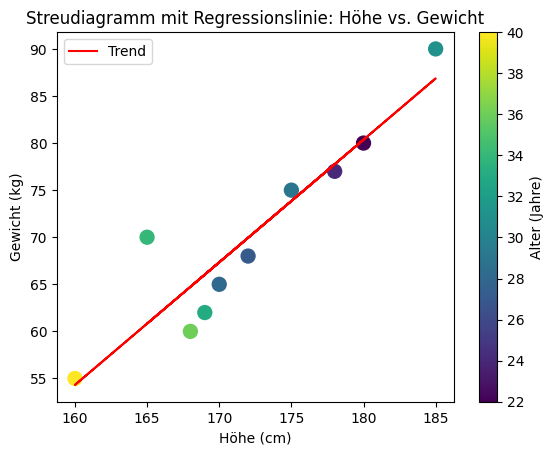

In [3]:
import numpy as np
import matplotlib.pyplot as plt
# Daten für 10 Personen: Höhe (cm), Gewicht (kg), Alter (Jahre), Ge
people_data = np.array([
    [170, 65, 28],
    [165, 70, 34],
    [180, 80, 22],
    [175, 75, 29],
    [160, 55, 40],
    [185, 90, 31],
    [172, 68, 27],
    [168, 60, 36],
    [178, 77, 24],
    [169, 62, 33]
])
# Höhe (cm) = people_data[:, 0], Gewicht (kg) = people_data[:, 1]
x_data = people_data[:, 0]
y_data = people_data[:, 1]

# Lineare Regression mit numpy.polyfit
m, b = np.polyfit(x_data, y_data, 1)
regression_line = m * x_data + b

plt.scatter(x_data, y_data, c=people_data[:, 2], s=100)
plt.plot(x_data, regression_line, color='red', label=f'Trend')
plt.colorbar(label='Alter (Jahre)')
plt.title('Streudiagramm mit Regressionslinie: Höhe vs. Gewicht')
plt.xlabel('Höhe (cm)')
plt.ylabel('Gewicht (kg)')

plt.legend()
plt.show()


### Beispiel: Interpolation mit `numpy.polyfit`
Die Funktion `numpy.polyfit` kann verwendet werden, um eine Polynominterpolation durch eine gegebene Menge von Datenpunkten durchzuführen.
- $N+1$ Datenpunkte $(x_i, y_i)$, $i=0,\ldots,N$ können durch ein Polynom $p(x)$ vom Grad $N$ exakt interpoliert werden.
- Es gilt also $p(x_i) = y_i$ für alle $i=0,\ldots,N$, für

$$
p(x) = \sum_{i=0}^N \prod_{j=0, j\neq i}^N \frac{x - x_j}{x_i - x_j} y_i
$$

- `numpy.polyfit(x_data, y_data, deg=N)` berechnet die Koeffizienten des Polynoms $p(x)=\sum_{i=0}^N a_i x^i$ in absteigender Potenzreihenfolge.
- `numpy.polyval(coefficients, x_values)` wertet das Polynom an den Stellen `x_values` aus.
    - Stabiler und effizienter als manuelles Auswerten mit $p(x)=\sum_{i=0}^N a_i x^i$.
- `numpy.poly1d(coefficients)` erstellt ein Polynom-Objekt, das wie eine Funktion verwendet werden kann.
- Wählt man den Grad des Polynoms kleiner als $N$, so erhält man eine Approximation der Datenpunkte im Sinne der kleinsten Quadrate

$$
\sum_{i=0}^N (y_i - p(x_i))^2 \longrightarrow\text{ minimal}
$$

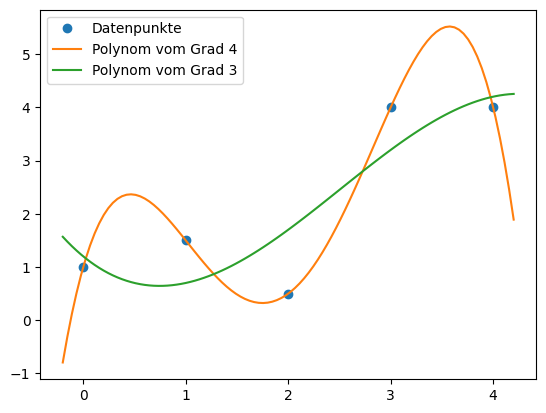

In [16]:
import numpy as np
import matplotlib.pyplot as plt
# Datenpunkte
x_data = np.array([0, 1, 2, 3, 4])
y_data = np.array([1, 1.5, 0.5, 4, 4])
# Polynominterpolation 
degree = len(x_data) - 1
coefs_interp = np.polyfit(x_data, y_data, deg=degree)
coefs_approx = np.polyfit(x_data, y_data, deg=3)
# Plot
x = np.linspace(-0.2, 4.2, 100)
px_interp = np.polyval(coefs_interp, x)
px_approx = np.polyval(coefs_approx, x)
plt.plot(x_data, y_data, 'o', label='Datenpunkte')
plt.plot(x, px_interp, '-', label=f'Polynom vom Grad {degree}')
plt.plot(x, px_approx, '-', label=f'Polynom vom Grad {degree-1}')
plt.legend()
plt.show()

## Gleichungssysteme lösen:
- `np.linalg.solve(A, b)`: Löst das lineare Gleichungssystem `Ax = b` für `x`, wobei `A` eine quadratische Matrix ist.
- __Achtung__: `np.linalg.inv(A)` sollte vermieden werden, um Gleichungssysteme zu lösen, da es numerisch instabil sein kann und ineffizient ist (mehr dazu in der Vorlesung "Numerische Mathematik").

Im folgenden Beispiel wollen wir das einfache Gleichungssystem

$$
2x_1 + 3x_2 = 8 \\
5x_1 + 7x_2 = 19
$$

lösen. Dazu schreiben wir es in Matrixform $Ax = b$ mit

$$
A = \begin{pmatrix}
2 & 3 \\
5 & 7
\end{pmatrix}, \quad
x = \begin{pmatrix}
x_1 \\
x_2
\end{pmatrix}, \quad
b = \begin{pmatrix}
8 \\
19
\end{pmatrix}
$$

Mathematisch erhält man die Lösung durch $x = A^{-1}b$. In Python verwenden wir jedoch `np.linalg.solve(A, b)` um Rundungsfehler zu minimieren.

In [18]:
A = np.array([[2,3],[5,7]])
b = np.array([8,19])
#x = np.linalg.solve(A,b)
x = np.linalg.inv(A)@ b
print("Lösung x von Ax=b:")
print("x=",x)

Lösung x von Ax=b:
x= [1. 2.]


### Beispiel: Lösen eines großen Gleichungssystems
Wir wollen ein elastisches Seil modellieren, das an beiden Enden festgehalten wird.
- Wir ersetzen das Seil durch $N+1$ Liniensegmente, die sich dehnen können und an den Knotenpunkten $i=0,\ldots,N+1$ mit den Positionen $(i,y_i)$ verbunden sind.
- Die Endpunkte sind fest: $y_0 = 0$ und $y_{N+1} = 0$.
- Auf jeden Knotenpunkt wirkt die Schwerkraft nach unten mit der Stärke 1.
- Die beiden benachbarten Segmente ziehen am $i$-ten Knotenpunkt mit einer Kraft, die proportional zur Länge des Segments ist. Der Einfachheit halber nehmen wir nur die Differenz der $y$-Koordinaten.
- Im Gleichgewichtszustand muss die vertikale Kraft an jedem inneren Knotenpunkt $i=1,\ldots,N$ null sein, es gilt also:

\begin{align*}
    0&=\text{Schwerkraft} + \text{Kraft durch linkes Segment} + \text{Kraft durch rechtes Segment}\\
     &=-1 + (y_{i-1} - y_i) + (y_{i+1} - y_i) \\
     - y_{i-1} + 2y_{i}- y_{i+1}&=-1 
\end{align*}

- Für die Randknotenpunkte $i=0$ und $i=N+1$ wissen wir bereits $y_0 = 0$ und $y_{N+1} = 0$.


In Matrixform fassen wir die Unbekannten $y = (y_1,\ldots, y_N)$ zusammen und betrachten das Gleichungssystem $My = b$ mit $b = (-1,\ldots, -1)\in \mathbb{R}^N$ und der tridiagonalen Matrix

$$
M = \begin{pmatrix}
2 & -1 & 0 & 0 & \cdots & 0 \\
-1 & 2 & -1 & 0 & \cdots & 0 \\
0 & -1 & 2 & -1 & \cdots & 0 \\
\vdots & \vdots & \vdots & \vdots & \ddots & \vdots \\
0 & 0 & 0 & -1 & 2 & -1 \\
0 & 0 & 0 & 0 & -1 & 2
\end{pmatrix} \in \mathbb{R}^{N\times N}
$$


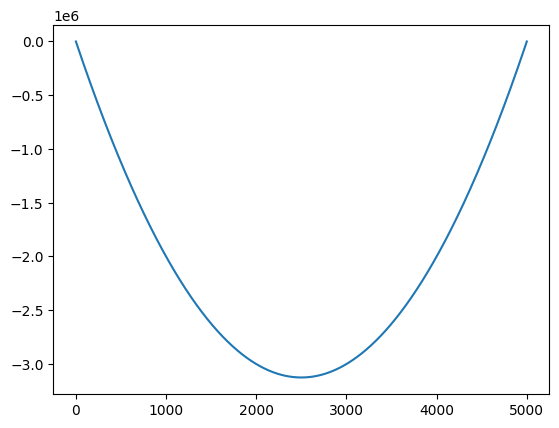

In [23]:
import numpy as np
import matplotlib.pyplot as plt
N = 5000
# Erstellen der Matrix M und des Vektors b
M = 2*np.eye(N) - np.diag(np.ones(N-1), k=-1) - np.diag(np.ones(N-1), k=1)
b = -np.ones(N)
# Lösen des Gleichungssystems My = b
y = np.linalg.solve(M, b)
# Wir ergänzen die Randbedingungen y_0 = 0 und y_{N+1} = 0
y_ext = np.concatenate(([0], y, [0])) 
# Plotten der Lösung
plt.plot(np.arange(0, N+2), y_ext, '-')
plt.show()

### Beispiel: Numerische Instabilität
Im folgenden Beispiel wollen wir demonstrieren, dass verschiedene Methoden die mathematisch äquivalent sind, am Computer unterschiedliche Ergebnisse liefern können. 
- Der Grund dafür sind Rundungsfehler, die bei der Berechnung auftreten können. 
- Manche Algorithmen sind weniger anfällig für diese Fehler als andere, weshalb es wichtig ist, die numerische Stabilität von Algorithmen zu berücksichtigen.

Wir betrachten die Matrix 

$$
A = \begin{pmatrix}
1& 1 + \varepsilon \\
1 + \varepsilon & 1
\end{pmatrix}
$$

und die exakte Lösung $x = (1,1)\in \mathbb{R}^2$ des Gleichungssystems $Ax = b$ mit $b = (2+\varepsilon, 2+\varepsilon)$. 
- Für $\varepsilon = 0$ wäre die Matrix singulär (nicht invertierbar) und daher das Gleichungssystem nicht eindeutig lösbar
    - In "Linearer Algebra" lernen Sie diesen Zusammenhang genauer kennen.
    - Für uns reicht es zu wissen, dass $\varepsilon =0 $ zum folgendem Gleichungssystem führt:

    $$
    x_1 + x_2 = b_1\\
    x_1 + x_2 = b_2
    $$
    
    - wenn $b_1 \neq b_2$ gibt es keine Lösung, wenn $b_1 = b_2$ gibt es unendlich viele Lösungen.
    
- Für kleine Werte von $\varepsilon$ ist die Matrix $A$ zwar invertierbar und das Gleichungssystem hat eine Eindeutige Lösung. Aber die Matrix ist so nahe an einer singulären Matrix, das numerische Probleme auftreten können.  
    - Das berechnen der Inversen von $A$ ist in diesem Fall numerisch instabil und kann zu großen Fehlern in der Lösung führen.
    - Das Verwenden von `np.linalg.solve` (Variante von Gauss-Elimination) ist in diesem Fall stabiler und liefert eine genauere Lösung.

__Nie die Inverse Matrix für das Lösen von Gleichungssystemen verwenden!__ 

In [24]:
eps = 1e-14
A = np.array([[1, 1+eps], [1+eps, 1]])
x_exact = np.array([1, 1])
b = np.array([2+eps, 2+eps])

# Lösung mit np.linalg.solve
x_solve = np.linalg.solve(A, b)

# Lösung mit Inverser Matrix
x_inv = np.linalg.inv(A) @ b
print(np.linalg.inv(A))

print("Fehler mit np.linalg.solve:", np.linalg.norm(x_solve - x_exact))
print("Fehler mit np.linalg.inv(A) @ b:", np.linalg.norm(x_inv - x_exact))

[[-5.00399959e+13  5.00399959e+13]
 [ 5.00399959e+13 -5.00399959e+13]]
Fehler mit np.linalg.solve: 7.0671603959302715e-15
Fehler mit np.linalg.inv(A) @ b: 0.006383602885715476


## Bilder laden und bearbeiten
- `mathplotlib.pyplot.imread()`: Lädt ein Bild und gibt es als NumPy-Array zurück.
- `mathplotlib.pyplot.imsave()`: Speichert ein NumPy-Array als Bild
- `mathplotlib.pyplot.imshow()`: Zeigt ein Bild aus einem NumPy-Array an.

Bilder werden in der Regel als 3D-Arrays gespeichert, wobei die erste Dimension die Höhe (Anzahl der Pixel in vertikaler Richtung), die zweite Dimension die Breite (Anzahl der Pixel in horizontaler Richtung) und die dritte Dimension die Farbkanäle (z.B. Rot, Grün, Blau für RGB-Bilder) repräsentiert.
- Die Farbwerte sind in der Regel im Bereich von 0 bis 255 für 8-Bit-Bilder oder von 0.0 bis 1.0 für normalisierte Bilder.


Image shape: (1024, 1024, 3)


(-0.5, 1023.5, 1023.5, -0.5)

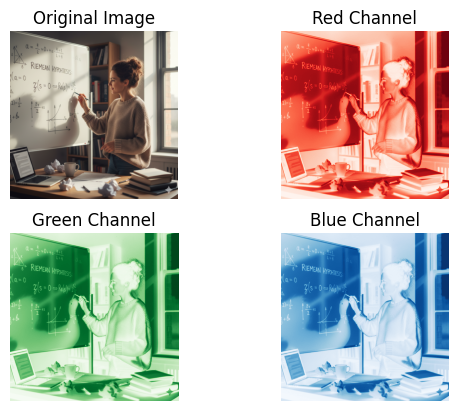

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

img = plt.imread('data/img.png')  # Bild laden             
print("Image shape:", img.shape)  # Bildabmessungen anzeigen
plt.subplot(2,2,1)
plt.title("Original Image")
plt.imshow(img)                   # Originalbild anzeigen
plt.axis('off')
plt.subplot(2,2,2)
plt.title("Red Channel")
plt.imshow(img[:,:,0], cmap='Reds')  # Roter Kanal anzeigen
plt.axis('off')
plt.subplot(2,2,3)
plt.title("Green Channel")
plt.imshow(img[:,:,1], cmap='Greens') # Grüner Kanal anzeigen
plt.axis('off')
plt.subplot(2,2,4)
plt.title("Blue Channel")
plt.imshow(img[:,:,2], cmap='Blues')  # Blauer Kanal anzeigen
plt.axis('off') 

Um das Bild in Graustufen umzuwandeln, kann man einfach den Durchschnitt der Farbkanäle berechnen. Dies reduziert die dritte Dimension des Arrays auf 1.
- Ein natürlicheres Ergebnis erhält man mit der Luminanzmethode, die die unterschiedlichen Wahrnehmungen der Farben durch das menschliche Auge berücksichtigt. 
- Dabei werden die Farbkanäle mit den Gewichten 0.2989 für Rot, 0.5870 für Grün und 0.1140 für Blau gewichtet.

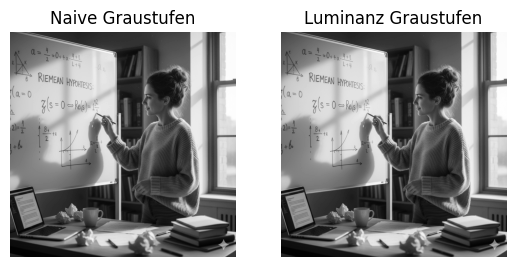

In [ ]:
grayscale_naive = img @ np.array([1/3, 1/3, 1/3])
grayscale_luminance = img @ np.array([0.2989, 0.5870, 0.1140])

plt.subplot(1,2,1)
plt.title("Naive Graustufen")
plt.imshow(grayscale_naive, cmap='gray')
plt.axis('off')
plt.subplot(1,2,2)
plt.title("Luminanz Graustufen")
plt.imshow(grayscale_luminance, cmap='gray')
plt.axis('off')
plt.show()
tmp = np.zeros((grayscale_luminance.shape[0], grayscale_luminance.shape[1],3))
tmp[...,0] = grayscale_luminance
tmp[...,1] = grayscale_luminance
tmp[...,2] = grayscale_luminance
plt.imsave('data/grayimg.png', tmp)